In [2]:
from sim_pipeline import *
from plot_helpers import *

import numpy as np

In [3]:
class SensorSelectorREINFORCE:
    def __init__(self, N, rho, lr=0.01, baseline_decay=0.95):
        self.N = N
        self.k = int(rho * N)
        self.lr = lr

        self.w = np.zeros(N)

        self.baseline = 0.0
        self.baseline_decay = baseline_decay

    def get_probs(self):
        exp_w = np.exp(self.w - np.max(self.w))
        return exp_w / np.sum(exp_w)

    def sample_subset(self, probs):
        return np.random.choice(self.N, size=self.k, replace=False, p=probs)

    def _grad_logp(self, subset, probs):
        grad = -probs.copy()
        grad[subset] += 1.0
        return grad

    def update(self, reward, subset, probs):
        # baseline update
        self.baseline = (
            self.baseline_decay * self.baseline +
            (1 - self.baseline_decay) * reward
        )

        adv = reward - self.baseline

        grad = self._grad_logp(subset, probs)

        self.w += self.lr * adv * grad

In [4]:
def train_sensor_selector(
    G, s0, lam,
    N, T, contacts, delta,
    rho, lr=0.01, baseline_decay=0.95,
    iterations=200,
    bp_iter=20,
    max_iter_bp=20,
    tol=1e-6,
    damp=0.5,
):

    selector = SensorSelectorREINFORCE(N, rho, lr=lr, baseline_decay=baseline_decay)

    reward_history = []
    for it in range(iterations):
        
        # --- 1) sample a NEW epidemic realization ---
        status_nodes = simulate_SI(G, s0, lam, T)

        probs = selector.get_probs()

        batch_rewards = []
        batch_grads = []

        # --- 2) multiple samples per iteration (variance reduction) ---
        for _ in range(5):

            subset = selector.sample_subset(probs)

            # build observations
            obs_rows = []
            for node in subset:
                for t in range(status_nodes.shape[0]):
                    obs_rows.append((node, int(status_nodes[t, node]), t))

            obs_array = (
                np.array(obs_rows, dtype=int)
                if len(obs_rows) > 0
                else np.empty((0, 3), dtype=int)
            )

            # --- 3) BP inference ---
            bp_fg = fg.FactorGraph(N, T, contacts, obs_array, delta)
            bp_fg.update(maxit=max_iter_bp, tol=tol, damp=damp)

            marg = bp_fg.marginals()
            Mt = get_Mt(marg, t=0)

            x_est = np.argmax(Mt, axis=0)

            # --- 4) reward ---
            reward = OV(x_est, status_nodes[0])

            adv = reward - selector.baseline
            grad = selector._grad_logp(subset, probs)

            batch_rewards.append(reward)
            batch_grads.append(adv * grad)

        # --- 5) aggregate gradients ---
        avg_grad = np.mean(batch_grads, axis=0)
        avg_reward = np.mean(batch_rewards)

        # --- 6) update baseline ---
        selector.baseline = (
            selector.baseline_decay * selector.baseline
            + (1 - selector.baseline_decay) * avg_reward
        )

        # --- 7) update parameters ---
        selector.w += selector.lr * avg_grad

        #print(f"iter {it}, avg_reward={avg_reward:.4f}")
        reward_history.append(avg_reward)
    return selector, reward_history

In [8]:
N = 100
d = 3
lam = 0.3
T_max = 10
delta = 0.3
Nsim = 5
rho_list = np.linspace(0.1, 1.0, 10)
ks = [int(rho * N) for rho in rho_list]

G, contacts, s0 = gen_graph_sim(N, d, lam=lam, T_max=T_max, delta=delta)
results_df = pd.DataFrame(columns=["sensor_type", "rho", "OV"])

ov_random_list = []
for rho in rho_list:
    for sim in range(Nsim):
        #G, contacts, s0 = gen_graph_sim(N, d, lam=lam, T_max=T_max, delta=delta)
        status_nodes = simulate_SI(G, s0, lam, T_max)

        obs_random = gen_sensor_obs(rho, status_nodes)
        bp_fg_random = fg.FactorGraph(N, T_max, contacts, obs_random, delta)
        bp_fg_random.update(maxit=20, tol=1e-6, damp=0.5)
        marg_random = bp_fg_random.marginals()
        Mt_random = get_Mt(marg_random, t=0)
        x_est_random = np.argmax(Mt_random, axis=0)
        ov_random = OV(x_est_random, status_nodes[0])
        #print(f"Random selection OV: {ov_random:.4f}")
        ov_random_list.append(ov_random)
        results_df.loc[len(results_df)] = ["random", rho, ov_random]
    #print("Random selection OVs:", ov_random_list)
    #print("Average OV:", np.mean(ov_random_list))

In [9]:
# initialize selection parameters
w = np.zeros(N)  # logits
baseline = 0.0
lr = 0.05
baseline_decay = 0.95

In [10]:
from tqdm import tqdm
selectors = {}
reward_histories = {}
for rho in tqdm(rho_list[::2]):
    selectors[rho], reward_histories[rho] = train_sensor_selector(
        G=G,
        s0=s0,
        lam=lam,
        N=N,
        T=T_max,
        contacts=contacts,
        delta=delta,
        rho=rho,
        lr=lr,
        baseline_decay=baseline_decay,
        iterations=100
    )

 20%|██        | 1/5 [01:02<04:09, 62.47s/it]


KeyboardInterrupt: 

In [ ]:
probs = {}
for rho in rho_list:
    probs[rho] = selectors[rho].get_probs()

In [138]:
ov_list = []

for rho in rho_list:
    for sim in range(Nsim):  
        selected_nodes = np.random.choice(N, size=selectors[rho].k, replace=False, p=probs[rho])
        #selected_nodes = np.argsort(-probs[rho])[:selectors[rho].k]

        obs_rows = []
        for node in selected_nodes:
            for t in range(T_max + 1):
                obs_rows.append((node, int(status_nodes[t, node]), t))

        obs_array = np.array(obs_rows, dtype=int)

        bp_fg = fg.FactorGraph(N, T_max, contacts, obs_array, delta)
        bp_fg.update(maxit=20, tol=1e-6, damp=0.5)

        marg = bp_fg.marginals()
        Mt = get_Mt(marg, t=0)

        x_est = np.argmax(Mt, axis=0)
        ov = OV(x_est, status_nodes[0])

        #print(f"Learned selection OV: {ov:.4f}")
        ov_list.append(ov)
        results_df.loc[len(results_df)] = ["learned", rho, ov]

print("Learned selection OVs:", ov_list)
print("Average OV:", np.mean(ov_list))

Learned selection OVs: [0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.6666666666666666, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.6666666666666666, 0.6666666666666666, 0.8333333333333334, 1.0, 0.8333333333333334, 0.6666666666666666, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.6666666666666666, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.6666666666666666, 0.6666666666666666, 0.8333333333333334, 1.0, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.6666666666666666, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 1.0, 0.8333333333333334, 0.6666666666666666, 1.0, 1.0, 0.8333333333333334, 0.8333333333333334, 1.0, 0.8333333333333334, 0.6666666666666666, 1.0, 0

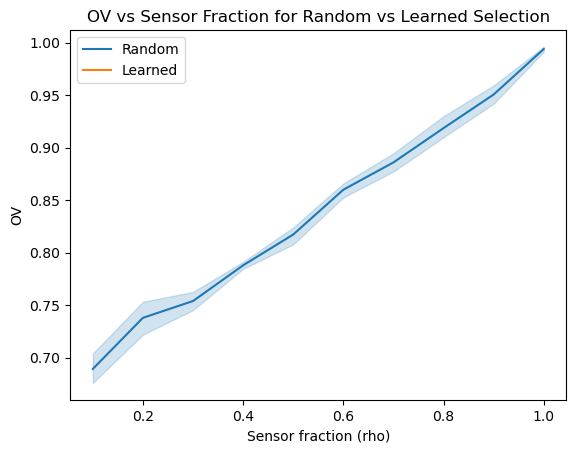

In [148]:
baseline_results = results_df[results_df["sensor_type"] == "random"]
learned_results = results_df[results_df["sensor_type"] == "learned"]

import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=baseline_results, x="rho", y="OV", label="Random")
sns.lineplot(data=learned_results, x="rho", y="OV", label="Learned")
plt.xlabel("Sensor fraction (rho)")
plt.ylabel("OV")
plt.title("OV vs Sensor Fraction for Random vs Learned Selection")
plt.legend()
plt.show()

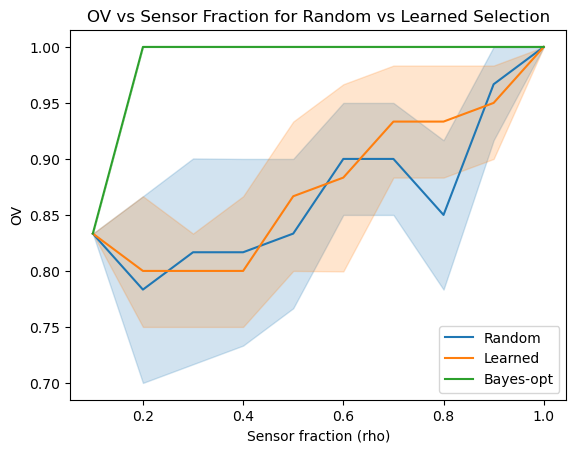

In [ ]:
bo_results = results_df[results_df["sensor_type"] == "bayes_opt"]

import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=baseline_results, x="rho", y="OV", label="Random")
sns.lineplot(data=learned_results, x="rho", y="OV", label="Learned")
sns.lineplot(data=bo_results, x="rho", y="OV", label="Bayes-opt")
plt.xlabel("Sensor fraction (rho)")
plt.ylabel("OV")
plt.title("OV vs Sensor Fraction for Random vs Learned Selection")
plt.legend()
plt.show()

In [1]:
results_df_smallN = results_df.copy()
# save in results directory
results_df_smallN.to_csv("results/sensor_selection_reinforce_smallN.csv", index=False)

NameError: name 'results_df' is not defined